# Mass-spring-damper displacement prediction
Dr Claire Villette - Adapted from Henderson 2022


## Problem definition


We are interested in modelling the displacement of a mass connected to a spring and a damper over time.

The displacement, $u(t)$, of the mass as a function of time can be described by the following governing differential equation:

$$
m \dfrac{d^2 u}{d t^2} + c \dfrac{d u}{d t} + ku = 0~,
$$

where $m$ is the mass of the oscillator, $c$ is the damper coefficient and $k$ is the spring constant.

We will focus on solving the problem in the **under-damped state**, i.e. where the damper doesn't fully suppress the oscillations but slowly damps them.

Mathematically, this occurs when:

$$
\delta < \omega_0~,~~~~~\mathrm{where}~~\delta = \dfrac{c}{2m}~,~\omega_0 = \sqrt{\dfrac{k}{m}}~.
$$

Furthermore, we consider the following initial conditions of the system:

$$
u(t=0) = 1~~,~~\dfrac{d u}{d t}(t=0) = 0~.
$$

For this particular case, the exact solution is known and given by:

$$
u(t) = e^{-\delta t}(D \cos(\phi + \omega t))~,~~~~~\mathrm{with}~~\omega=\sqrt{\omega_0^2 - \delta^2}~.
$$


Reference: Henderson 2022: https://colab.research.google.com/github/Frenz86/DeepLearning/blob/main/python/PINN/PINN_physicNN.ipynb 

### Tasks

In this exercise, we will:

Part 1:
*   Generate synthetic mass displacement data using the analytical solution of the governing equation
*   Train and evaluate a multilayer perceptron model
*   Train and evaluate a Physics-Informed Neural Network model

Part 2:
*   Evaluate the PINN sensitivity to available data domain (time range) and data granularity (number of time points)
*   Evaluate the PINN sensitivity to loss function term scaling

Part 3 (to go further):
*   Use the PINN model in an inverse problem where the task is to estimate damping parameter $c$ based on noisy data








### Import relevant modules

We can solve Ordinary Differential Equations (ODEs) using *odeint*. However in this particular case it is easier to simply use the known analytical solution to the problem to generate synthetic data.

In [1]:
!pip install torch

import torch
import numpy as np
#from scipy.integrate import odeint       # Needed if aiming to solve differential equation; not needed if using analytical ODE solution directly
import matplotlib.pyplot as plt
from PIL import Image

###

## ODE parameters and function


In [2]:
# Considering mass m=1 for simplicity
d, wn = 2, 20
c, k = 2*d, wn**2

In [3]:
def exact_solution(d, wn, t):
    "Defines the analytical solution to the under-damped mass-spring-damper problem above."
    assert d < wn
    w = np.sqrt(wn**2-d**2)
    phi = np.arctan(-d/w)
    D = 1/np.cos(phi)
    cos = torch.cos(phi+w*t)
    exp = torch.exp(-d*t)
    u = exp*D*cos
    return u

# Part 1

## ODE simulation

In [4]:
# ODE simulation
t_test = torch.linspace(0,1,300).view(-1,1)
u_exact = exact_solution(d, wn, t_test)

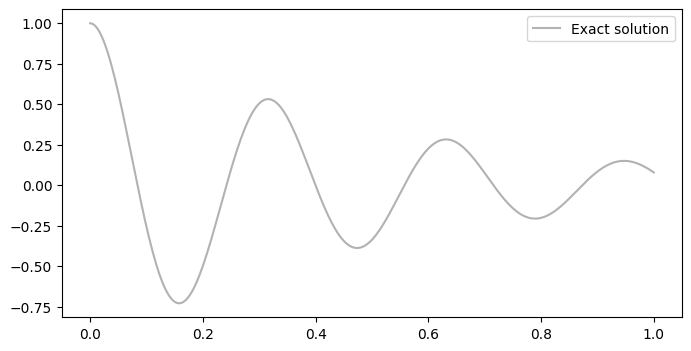

In [5]:
# ODE visualisation
plt.figure(figsize=(8,4))
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.legend()
plt.show()

## Traditional neural network model

### Build fully connected network

In [6]:
class FCN(torch.nn.Module):
    """Defines a standard fully-connected
        network in PyTorch"""

    def __init__(self, N_INPUT, N_OUTPUT, N_HIDDEN, N_LAYERS):
        super().__init__()
        activation = torch.nn.Tanh
        self.fcs = torch.nn.Sequential(*[torch.nn.Linear(N_INPUT, N_HIDDEN),activation()])
        self.fch = torch.nn.Sequential(*[torch.nn.Sequential(*[torch.nn.Linear(N_HIDDEN, N_HIDDEN),activation()]) for _ in range(N_LAYERS-1)])
        self.fce = torch.nn.Linear(N_HIDDEN, N_OUTPUT)

    def forward(self, x):
        x = self.fcs(x)
        x = self.fch(x)
        x = self.fce(x)
        return x

### Train FCN

In [ ]:
# sample solution to use as synthetic data (exact measurements)
# define training points over a subdomain, for the data loss
training_time_frame=100
sampling_step=10
t_data = t_test[0:training_time_frame:sampling_step]
u_data = u_exact[0:training_time_frame:sampling_step]

In [ ]:
# alternative synthetic data generation for noisy data

# noiselevel=0.04
# t_data = 0.3*torch.rand(20).view(-1,1)
# u_data = exact_solution(d, wn, t_data) + noiselevel*torch.randn_like(t_data)

In [64]:
torch.manual_seed(123)

# define a neural network to train
neuralnet = FCN(1,1,32,3)
optimiser = torch.optim.Adam(neuralnet.parameters(),lr=1e-3)

# training loop
for i in range(2000):
    optimiser.zero_grad()
    yh = neuralnet(t_data)

    # compute data loss
    loss = torch.mean((yh-u_data)**2)# use mean squared error

    # backpropagate loss, take optimiser step
    loss.backward()
    optimiser.step()



### Plot results

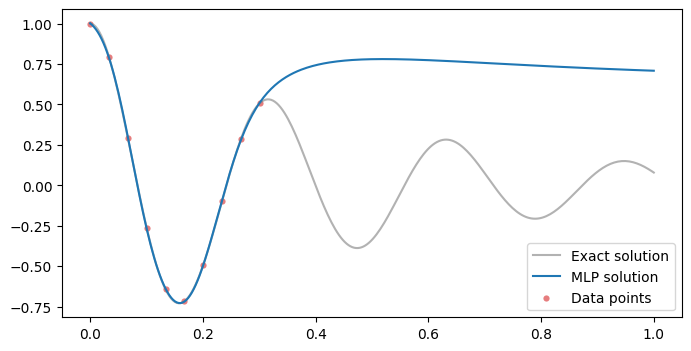

In [65]:
u = neuralnet(t_test).detach()

plt.figure(figsize=(8,4))
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.plot(t_test[:,0], u[:,0], label="MLP solution", color="tab:blue")
plt.scatter(t_data.detach()[:,0],
                    u_data.detach()[:,0], label="Data points",s=20, lw=0, color="tab:red", alpha=0.6)
plt.legend()
plt.show()

##

## Physics-Informed Neural Network

In [66]:
# define collocation time points over the entire domain, for the physics loss
t_physics = torch.linspace(0,1,30).view(-1,1).requires_grad_(True)

In [73]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)
optimiser = torch.optim.Adam(pinn.parameters(),lr=1e-3)

# training loop
for i in range(10000):  # likely to require higher training step number than standard MLP
    optimiser.zero_grad()

    # compute data loss
    yh = pinn(t_data)
    loss1 = torch.mean((yh-u_data)**2)# use mean squared error

    # compute physics loss
    u = pinn(t_physics)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss2 = torch.mean((d2udt2 + c*dudt + k*u)**2)

    # define aggregated loss
    lambda1=1
    lambda2=1e-4
    loss=lambda1*loss1+lambda2*loss2

    # backpropagate loss, take optimiser step
    loss.backward()
    optimiser.step()


### Plot results

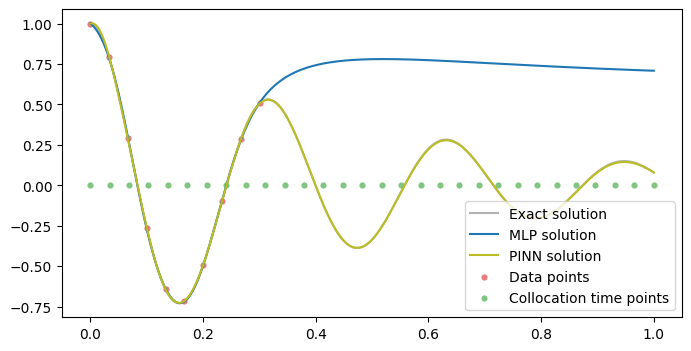

In [74]:
u = neuralnet(t_test).detach()
upinn = pinn(t_test).detach()

plt.figure(figsize=(8,4))
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.plot(t_test[:,0], u[:,0], label="MLP solution", color="tab:blue")
plt.plot(t_test[:,0], upinn[:,0], label="PINN solution", color="tab:olive")
plt.scatter(t_data.detach()[:,0],
                    u_data.detach()[:,0], label="Data points",s=20, lw=0, color="tab:red", alpha=0.6)
plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], label="Collocation time points",s=20, lw=0, color="tab:green", alpha=0.6)
plt.legend()
plt.show()

# Part 2

This part is exploratory.

Vary the parameters below and compare goodness of fit between predictions and exact solution for both neural networks:

*   Width of time frame spanned by training data points (highest red dot time)
*   Number of training data points (number of red dots)
*   Number of collocation points (green dots)
*   Number of training iterations
*   Lambda parameters to modulate relative importance of both loss terms
*   Noise level in training data (red dots)


Expected observations are:

*   Stronger negative impact of decreased training data size on MLP fit than PINN
*   Negative impact of reduced number of collocation points on PINN fit
*   Higher number of training iterations required for convergence of PINN versus MLP
*   Negative impact of high lambda2 values (eg: 1e-1) on PINN fit
*   Negative impact of very low lambda2 values (eg: 1e-6) on PINN fit
*  Stronger impact of increased noise in training data on MLP than PINN








In [ ]:
# To generate noisy syntetic training data, select random time points and add random noise to the exact solution
# Use this synthetic training data generation snippet instead of the

# Part 3

The task here is to use a PINN to **invert** for underlying parameters.

Specifically, our inputs and outputs are:

- Inputs: noisy observations of the oscillator's displacement
- Outputs: estimate $c$, the damping coefficient


The key idea here is to also treat $c$ as a **learnable parameter** when training the PINN - so that we both simulate the solution and invert for this parameter. This declaration is done in the optimiser definition.


In [80]:
# generate noisy synthetic training data
noiselevel=0.04
t_data = torch.rand(40).view(-1,1)
u_data = exact_solution(d, wn, t_data) + noiselevel*torch.randn_like(t_data)

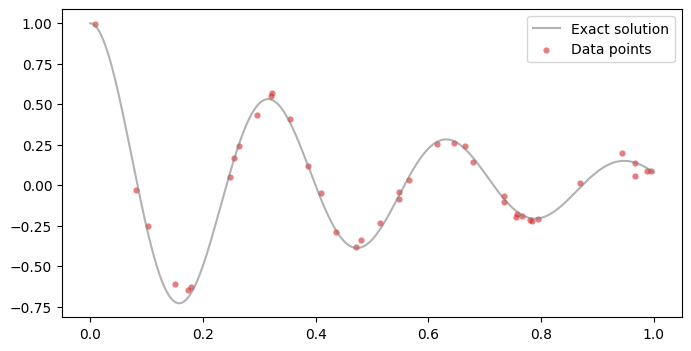

In [81]:
# plot training data
plt.figure(figsize=(8,4))
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.scatter(t_data.detach()[:,0],
                    u_data.detach()[:,0], label="Data points",s=20, lw=0, color="tab:red", alpha=0.6)
plt.legend()
plt.show()


In [102]:
# treat c as a learnable parameter (and carry information in optimiser in next cell)
c = torch.nn.Parameter(torch.zeros(1, requires_grad=True))
cs = []

In [103]:
torch.manual_seed(123)

# define a neural network to train
pinn = FCN(1,1,32,3)
optimiser = torch.optim.Adam(list(pinn.parameters())+[c],lr=1e-3)  #  parameter c is indicated as a learnable parameter

# training loop
for i in range(18000):
    optimiser.zero_grad()

    # compute data loss
    yh = pinn(t_data)
    loss1 = torch.mean((yh-u_data)**2)# use mean squared error

    # compute physics loss
    u = pinn(t_physics)
    dudt = torch.autograd.grad(u, t_physics, torch.ones_like(u), create_graph=True)[0]
    d2udt2 = torch.autograd.grad(dudt, t_physics, torch.ones_like(dudt), create_graph=True)[0]
    loss2 = torch.mean((d2udt2 + c*dudt + k*u)**2)

    # define aggregated loss
    lambda1=1
    lambda2=1e-4
    loss=lambda1*loss1+lambda2*loss2

    # backpropagate loss, take optimiser step
    loss.backward()
    optimiser.step()

    # record c value
    cs.append(c.item())

In [104]:
# print estimated value of c
print(f"True value of c: {2*d}")
ce=c.detach()
print(f"Estimated value of c: {ce[0]}")

True value of c: 4
Estimated value of c: 3.654568672180176


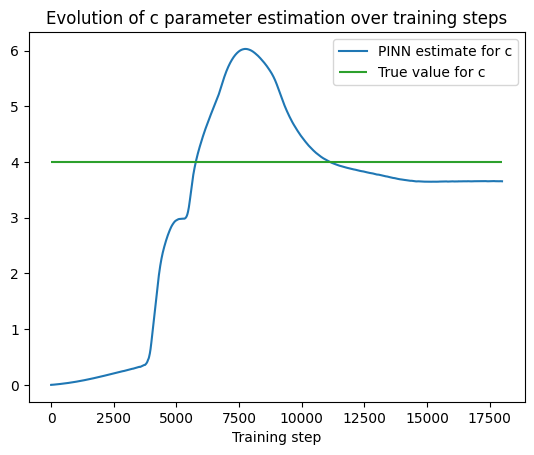

In [105]:
# plot evolution of c estimation over training steps
plt.figure()
plt.title("Evolution of c parameter estimation over training steps")
plt.plot(cs, label="PINN estimate for c")
plt.hlines(2*d, 0, len(cs), label="True value for c", color="tab:green")
plt.legend()
plt.xlabel("Training step")
plt.show()

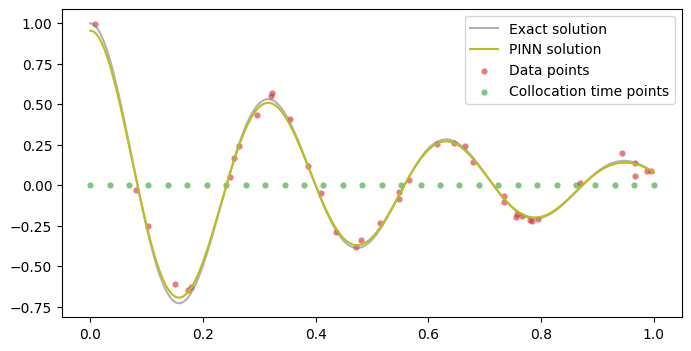

In [91]:
# plot final PINN results
upinn = pinn(t_test).detach()

plt.figure(figsize=(8,4))
plt.plot(t_test[:,0], u_exact[:,0], label="Exact solution", color="tab:grey", alpha=0.6)
plt.plot(t_test[:,0], upinn[:,0], label="PINN solution", color="tab:olive")
plt.scatter(t_data.detach()[:,0],
                    u_data.detach()[:,0], label="Data points",s=20, lw=0, color="tab:red", alpha=0.6)
plt.scatter(t_physics.detach()[:,0],
                    torch.zeros_like(t_physics)[:,0], label="Collocation time points",s=20, lw=0, color="tab:green", alpha=0.6)
plt.legend()
plt.show()